# Exploratory Data Analysis

This notebook explores the distributions and relationships within the obesity-risk dataset.

## Objectives

- Analyse numerical feature distributions
- Examine categorical feature frequencies
- Compare features with obesity-risk classes
- Identify skewness, outliers, and unusual patterns
- Understand relationships before preprocessing and modelling

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "obesity.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (20758, 18)


In [3]:
identifier_column = "id"
target_column = "NObeyesdad"

numerical_features = [
    "Age",
    "Height",
    "Weight",
    "FCVC",
    "NCP",
    "CH2O",
    "FAF",
    "TUE",
]

categorical_features = [
    "Gender",
    "family_history_with_overweight",
    "FAVC",
    "CAEC",
    "SMOKE",
    "SCC",
    "CALC",
    "MTRANS",
]

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 8
Categorical features: 8


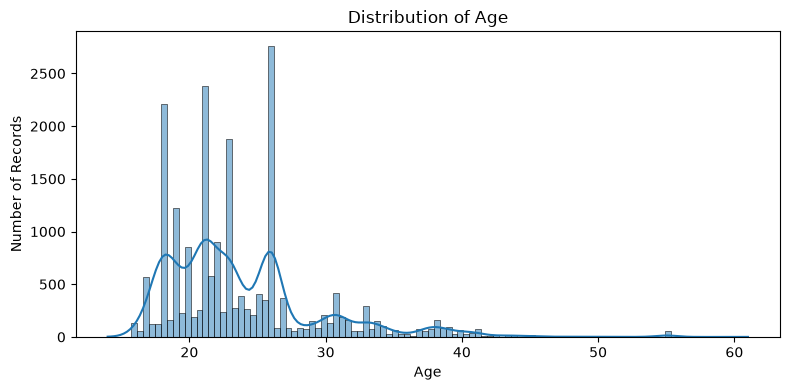

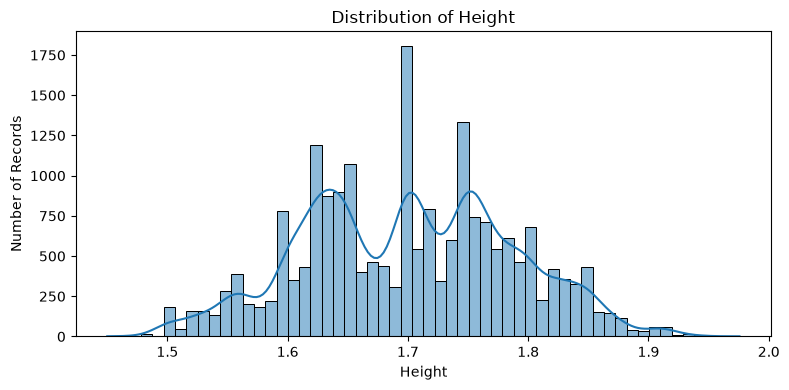

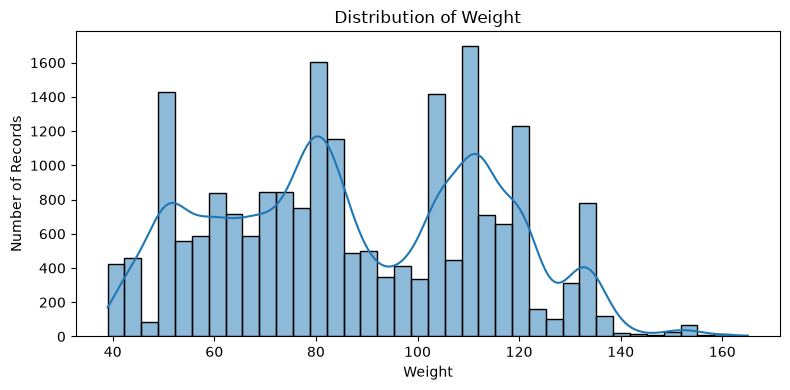

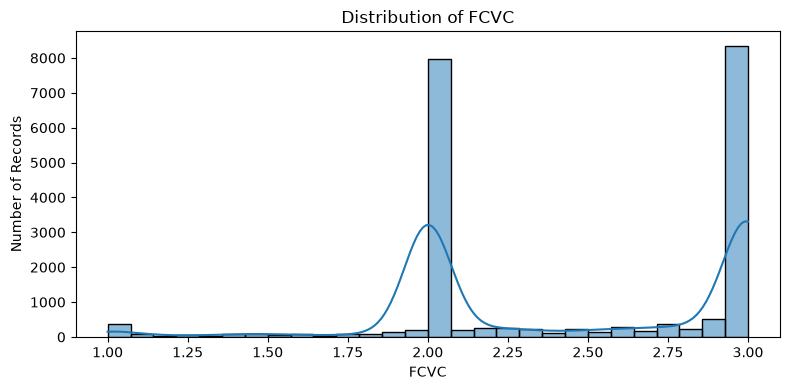

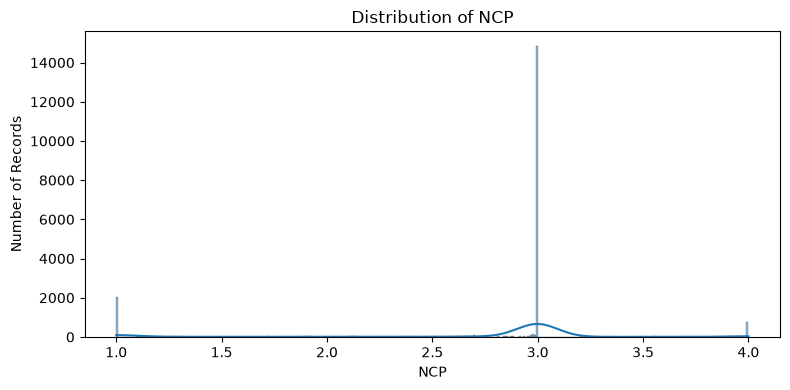

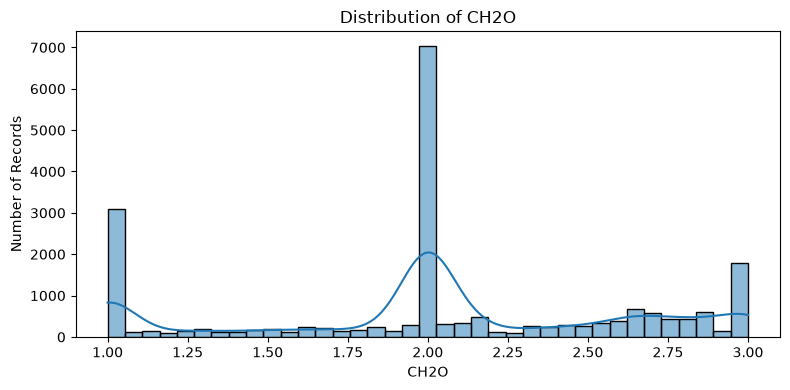

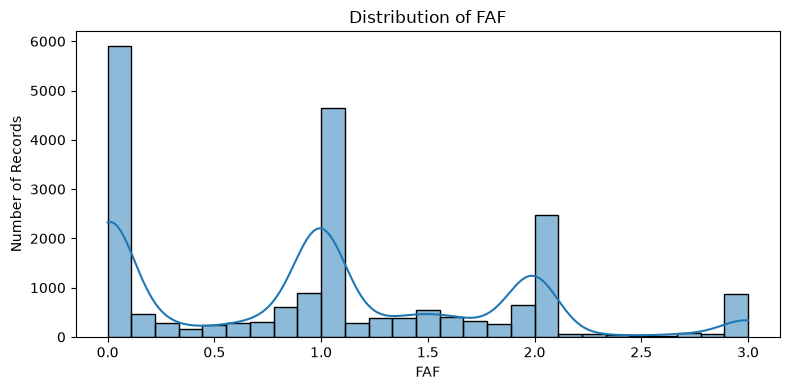

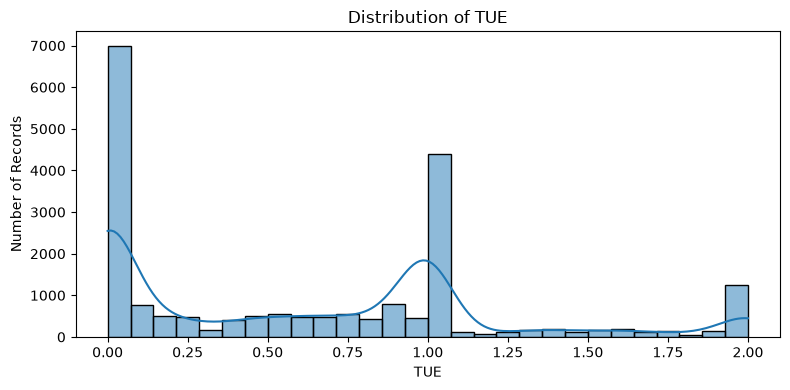

In [4]:
for column in numerical_features:
    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=df,
        x=column,
        kde=True,
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Records")
    plt.tight_layout()
    plt.show()

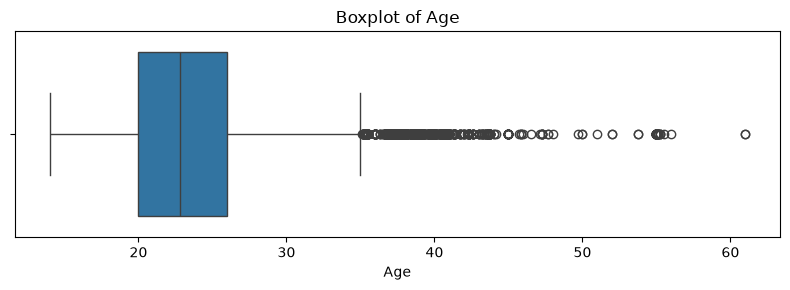

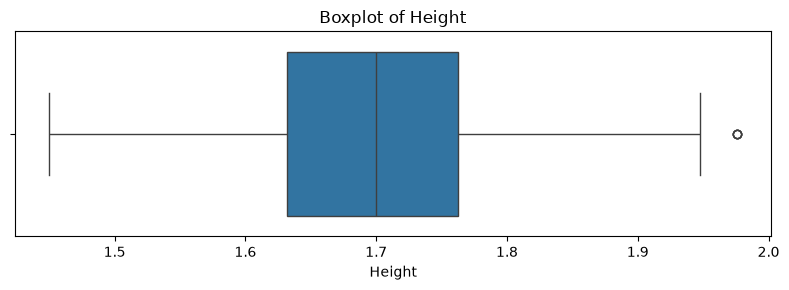

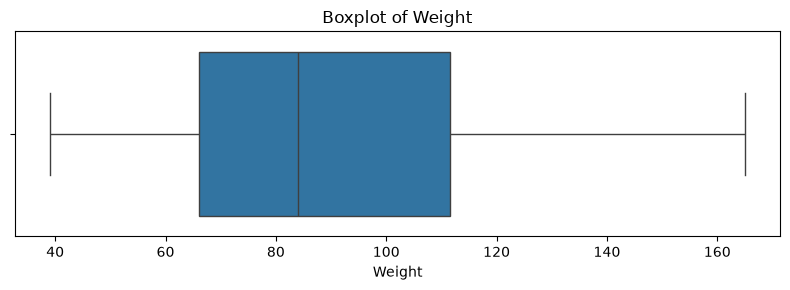

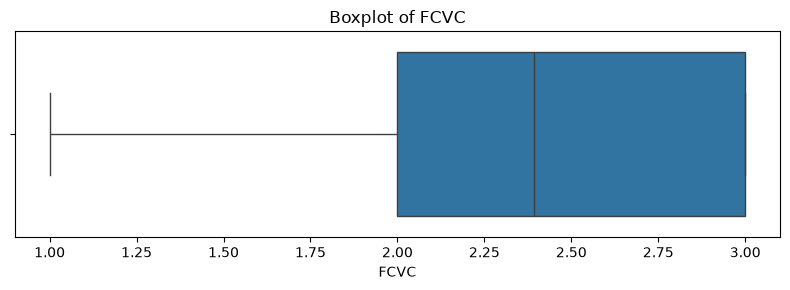

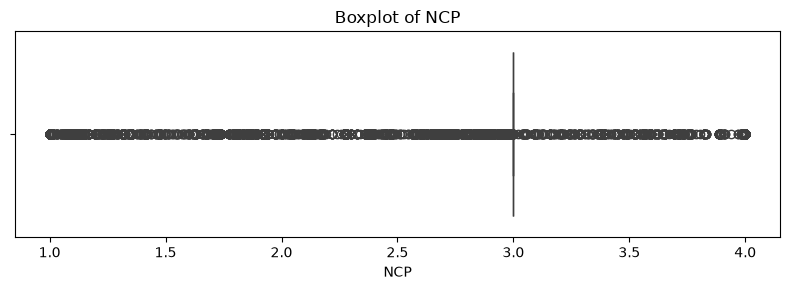

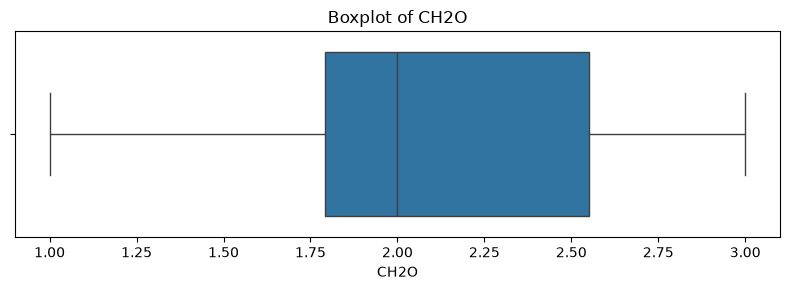

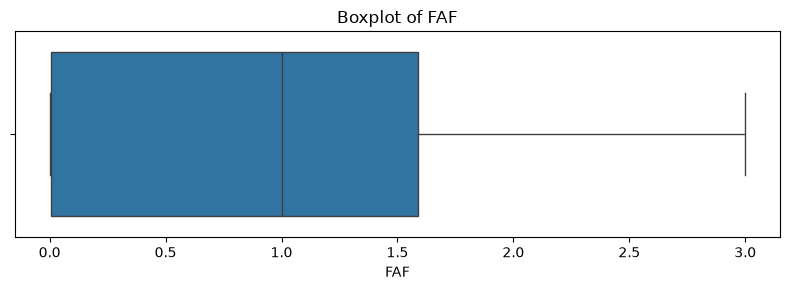

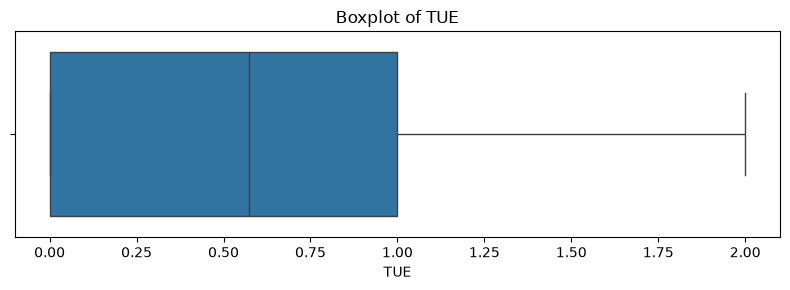

In [5]:
for column in numerical_features:
    plt.figure(figsize=(8, 3))

    sns.boxplot(
        data=df,
        x=column,
    )

    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.tight_layout()
    plt.show()

In [6]:
for column in categorical_features:
    category_counts = df[column].value_counts()
    category_percentages = (
        df[column]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    category_summary = pd.DataFrame({
        "Count": category_counts,
        "Percentage": category_percentages,
    })

    print(f"\n{column}")
    print("-" * len(column))
    display(category_summary)


Gender
------


,Count,Percentage
Gender,,
Female,10422,50.21
Male,10336,49.79



family_history_with_overweight
------------------------------


,Count,Percentage
family_history_with_overweight,,
yes,17014,81.96
no,3744,18.04



FAVC
----


...

,Count,Percentage
SCC,,
no,20071,96.69
yes,687,3.31



CALC
----


,Count,Percentage
CALC,,
Sometimes,15066,72.58
no,5163,24.87
Frequently,529,2.55



MTRANS
------


,Count,Percentage
MTRANS,,
Public_Transportation,16687,80.39
Automobile,3534,17.02
Walking,467,2.25
Motorbike,38,0.18
Bike,32,0.15


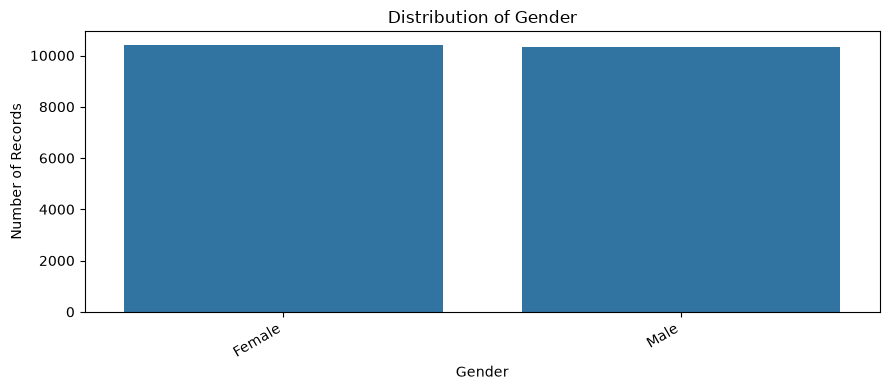

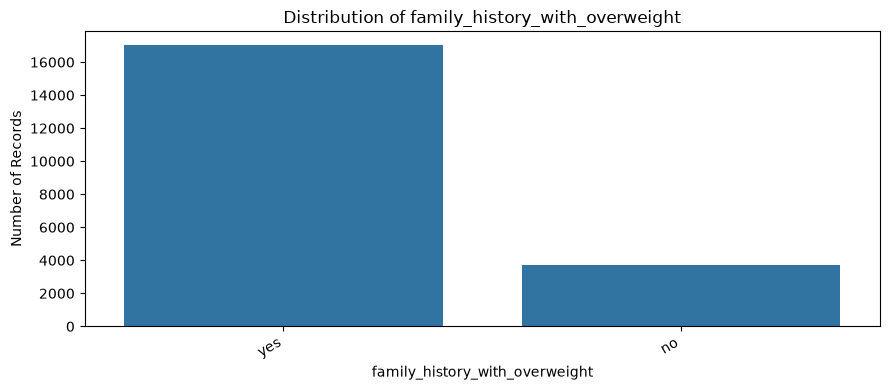

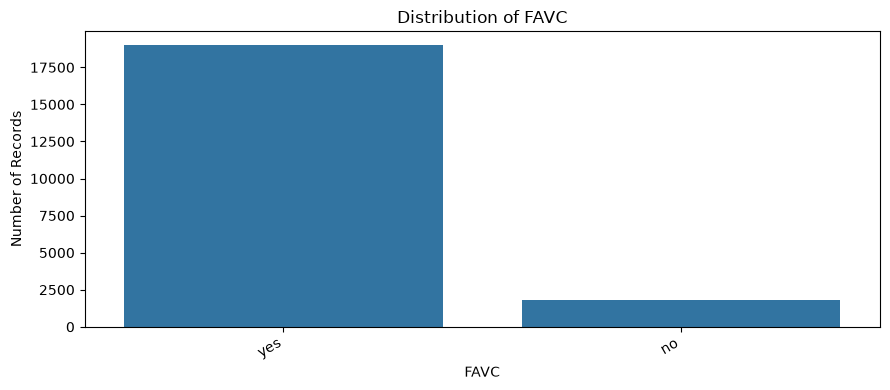

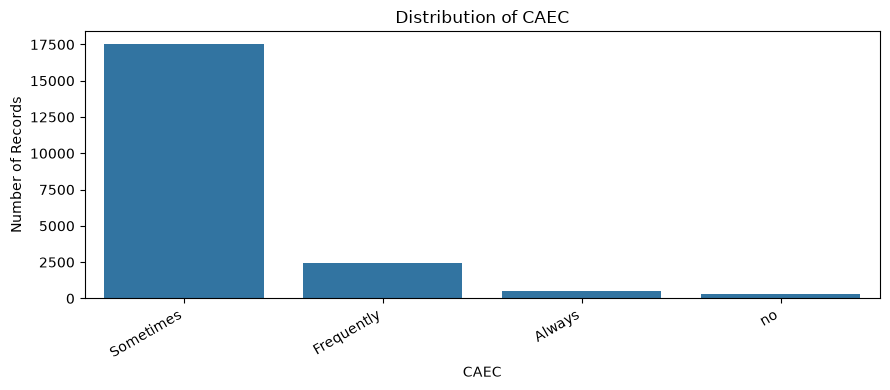

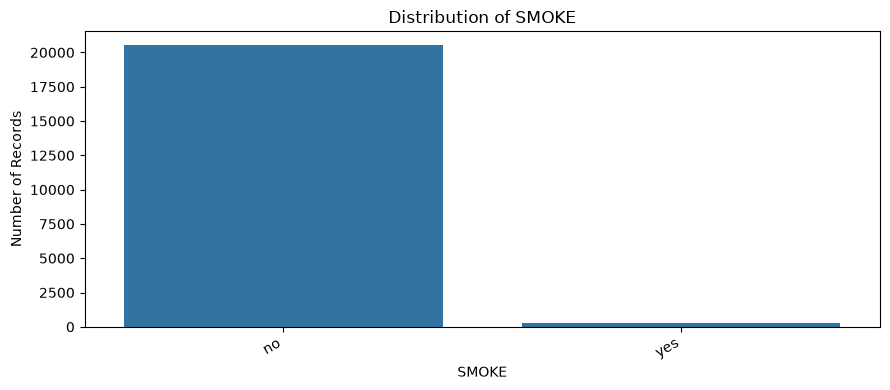

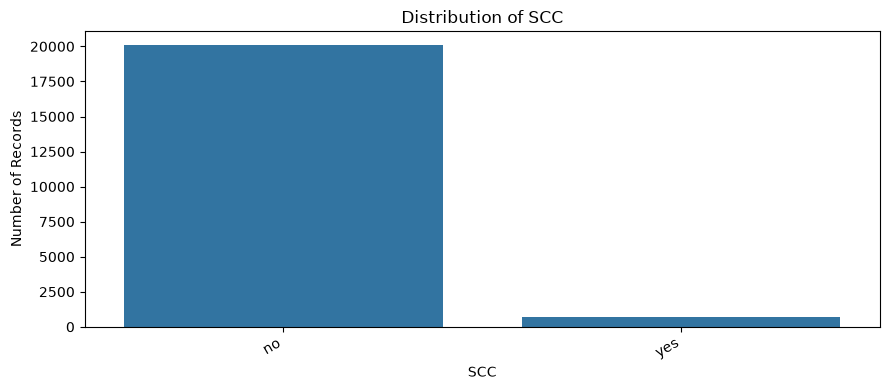

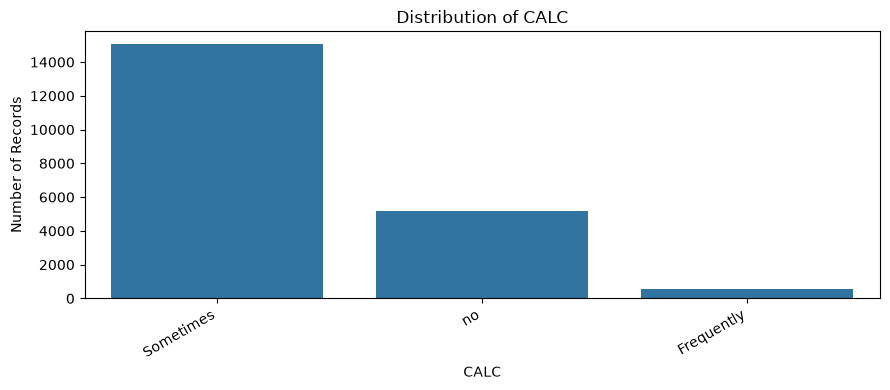

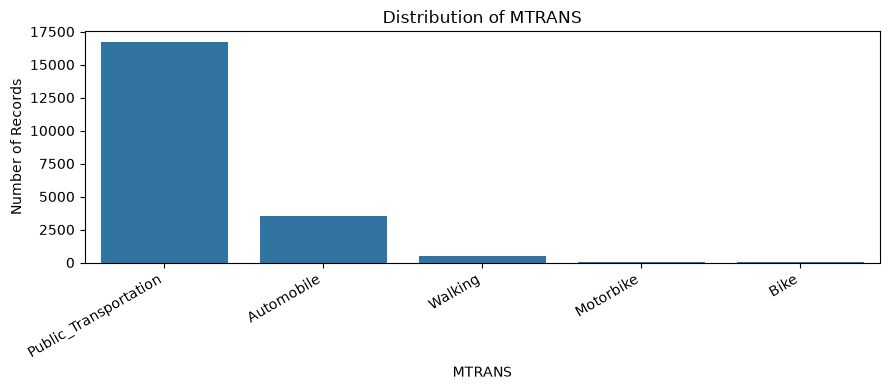

In [7]:
for column in categorical_features:
    category_order = df[column].value_counts().index

    plt.figure(figsize=(9, 4))

    sns.countplot(
        data=df,
        x=column,
        order=category_order,
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Records")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

In [8]:
category_extremes = []

for column in categorical_features:
    counts = df[column].value_counts()

    category_extremes.append({
        "Feature": column,
        "Most common category": counts.idxmax(),
        "Most common count": counts.max(),
        "Least common category": counts.idxmin(),
        "Least common count": counts.min(),
    })

category_extremes_df = pd.DataFrame(category_extremes)

category_extremes_df

,Feature,Most common category,Most common count,Least common category,Least common count
0,Gender,Female,10422,Male,10336
1,family_history_with_overweight,yes,17014,no,3744
2,FAVC,yes,18982,no,1776
3,CAEC,Sometimes,17529,no,279
4,SMOKE,no,20513,yes,245
5,SCC,no,20071,yes,687
6,CALC,Sometimes,15066,Frequently,529
7,MTRANS,Public_Transportation,16687,Bike,32


In [9]:
category_concentration = []

for column in categorical_features:
    most_common_percentage = (
        df[column]
        .value_counts(normalize=True)
        .max()
        * 100
    )

    category_concentration.append({
        "Feature": column,
        "Largest category percentage": round(
            most_common_percentage,
            2,
        ),
    })

category_concentration_df = pd.DataFrame(
    category_concentration
).sort_values(
    by="Largest category percentage",
    ascending=False,
)

category_concentration_df

,Feature,Largest category percentage
4,SMOKE,98.82
5,SCC,96.69
2,FAVC,91.44
3,CAEC,84.44
1,family_history_with_overweight,81.96
7,MTRANS,80.39
6,CALC,72.58
0,Gender,50.21


In [10]:
class_order = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
]

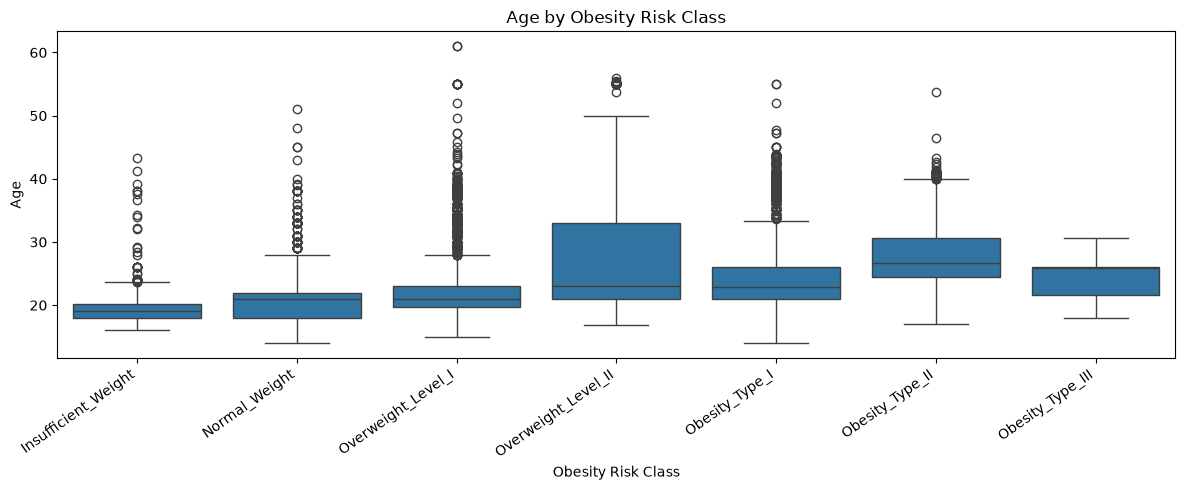

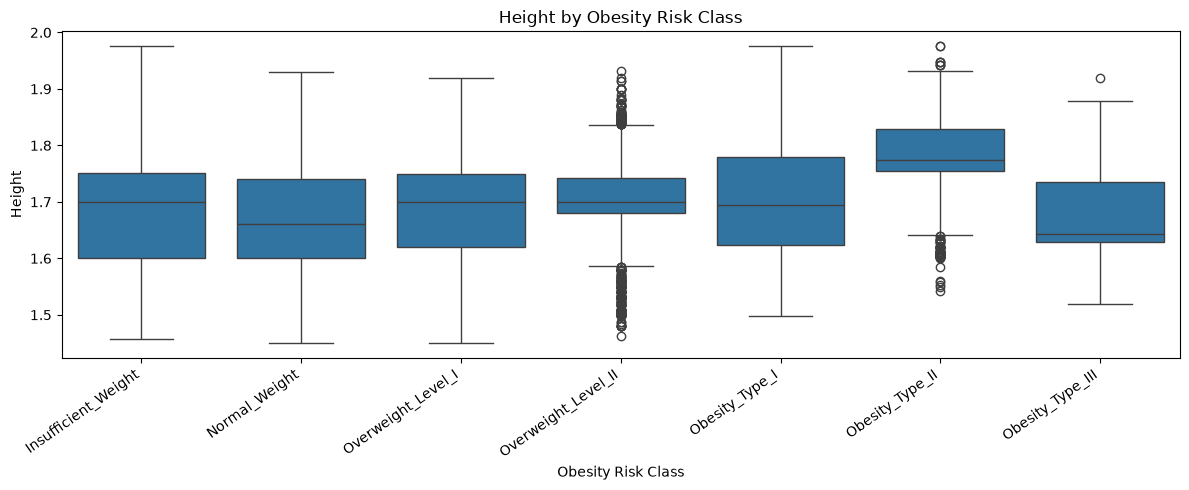

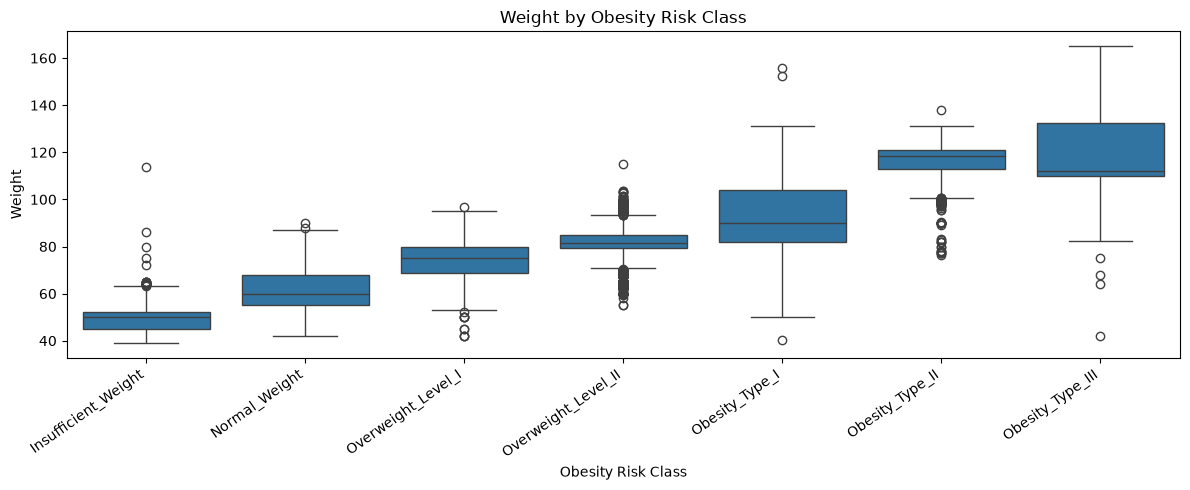

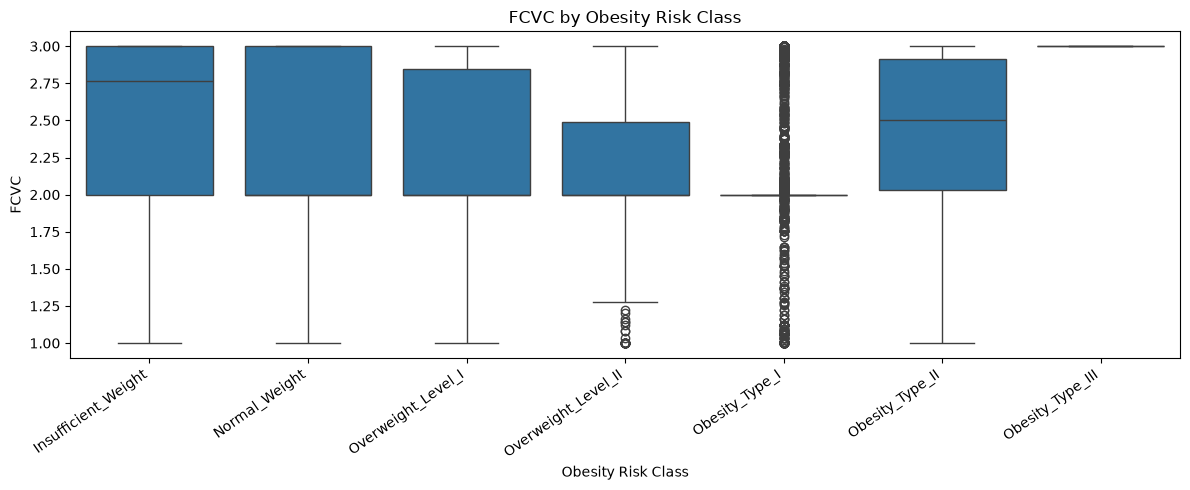

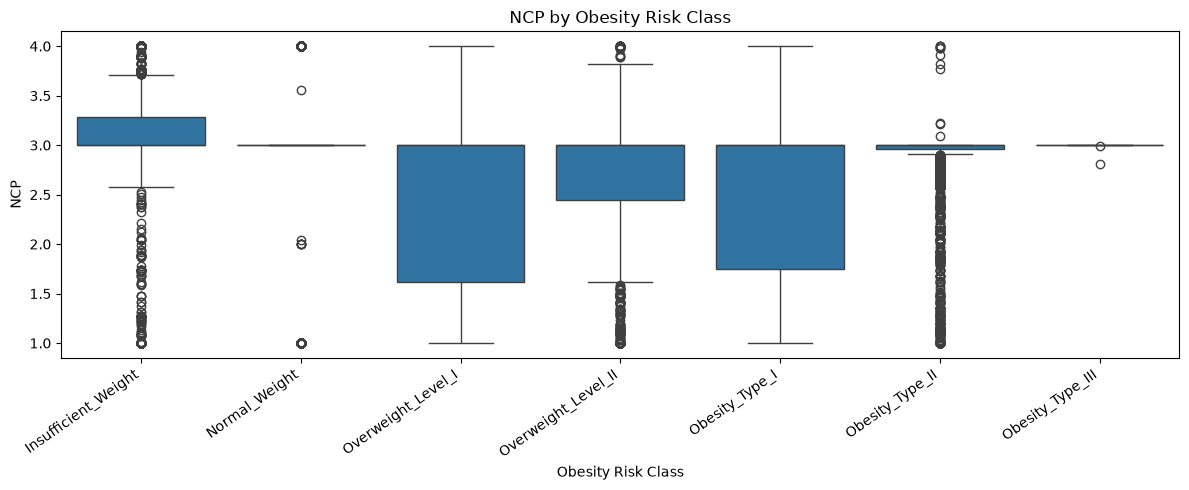

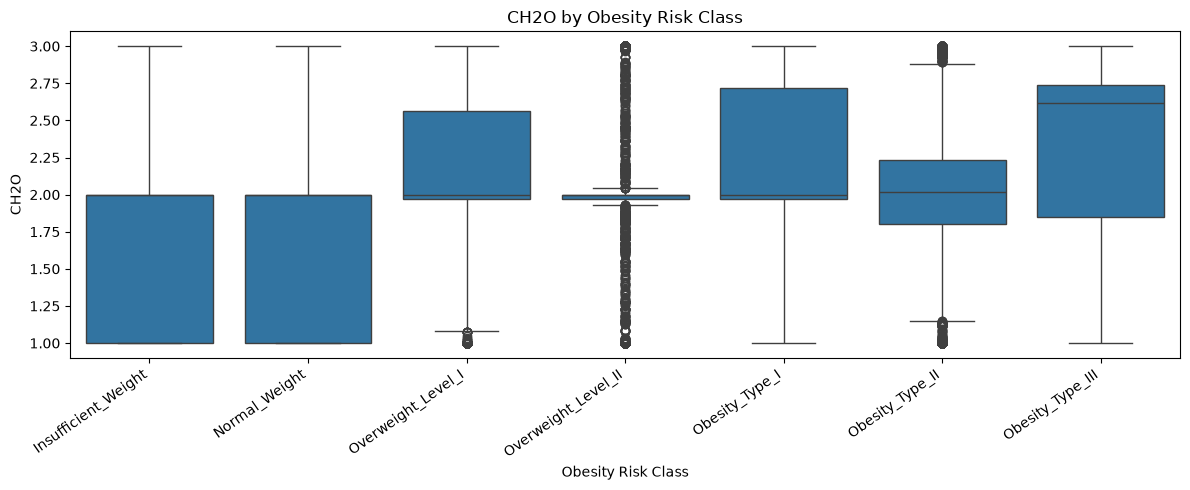

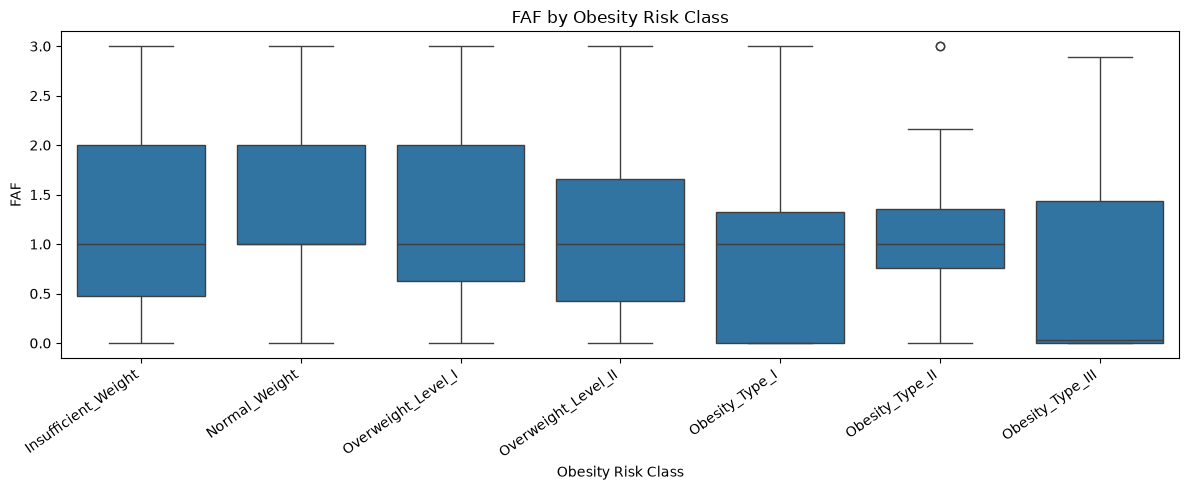

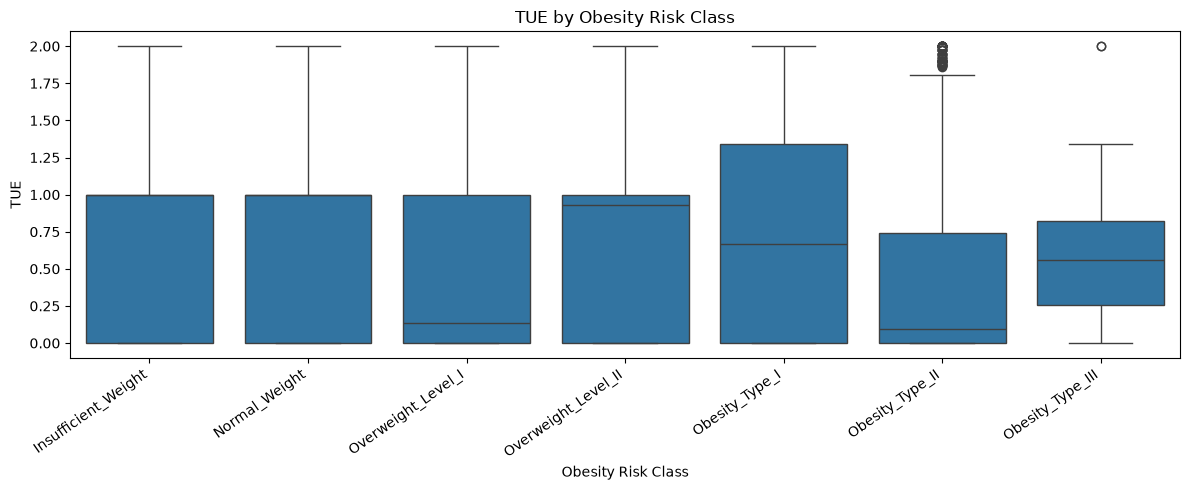

In [11]:
for column in numerical_features:
    plt.figure(figsize=(12, 5))

    sns.boxplot(
        data=df,
        x=target_column,
        y=column,
        order=class_order,
    )

    plt.title(f"{column} by Obesity Risk Class")
    plt.xlabel("Obesity Risk Class")
    plt.ylabel(column)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

In [12]:
numerical_class_medians = (
    df.groupby(target_column)[numerical_features]
    .median()
    .reindex(class_order)
    .round(2)
)

numerical_class_medians

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
NObeyesdad,,,,,,,,
Insufficient_Weight,19.00,1.70,50.00,2.77,3.0,2.00,1.00,1.00
Normal_Weight,21.00,1.66,60.00,2.00,3.0,2.00,1.00,1.00
Overweight_Level_I,21.00,1.70,75.00,2.00,3.0,2.00,1.00,0.13
Overweight_Level_II,23.00,1.70,81.63,2.00,3.0,2.00,1.00,0.93
Obesity_Type_I,22.85,1.69,90.12,2.00,3.0,2.00,1.00,0.67
Obesity_Type_II,26.70,1.77,118.33,2.50,3.0,2.01,1.00,0.09
Obesity_Type_III,25.96,1.64,111.91,3.00,3.0,2.62,0.04,0.56


In [13]:
for column in categorical_features:
    percentage_table = (
        pd.crosstab(
            df[column],
            df[target_column],
            normalize="index",
        )
        .mul(100)
        .reindex(columns=class_order)
        .round(1)
    )

    print(f"\n{column}")
    display(percentage_table)


Gender


NObeyesdad,Insufficient_Weight,Normal_Weight,Overweight_Level_I,Overweight_Level_II,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III
Gender,,,,,,,
Female,15.6,15.9,10.3,7.2,12.2,0.1,38.8
Male,8.7,13.8,13.1,17.1,15.9,31.3,0.0



family_history_with_overweight


NObeyesdad,Insufficient_Weight,Normal_Weight,Overweight_Level_I,Overweight_Level_II,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III
family_history_with_overweight,,,,,,,
no,38.7,34.5,20.2,5.2,1.3,0.1,0.0
yes,6.3,10.5,9.8,13.7,16.8,19.1,23.8



FAVC


...

NObeyesdad,Insufficient_Weight,Normal_Weight,Overweight_Level_I,Overweight_Level_II,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III
SCC,,,,,,,
no,11.4,14.6,10.9,12.4,14.4,16.2,20.2
yes,33.8,23.3,36.2,3.5,2.6,0.6,0.0



CALC


NObeyesdad,Insufficient_Weight,Normal_Weight,Overweight_Level_I,Overweight_Level_II,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III
CALC,,,,,,,
Frequently,2.6,12.9,24.6,43.1,14.4,2.5,0.0
Sometimes,10.8,12.9,13.0,8.5,9.6,18.4,26.9
no,17.2,20.8,6.5,19.7,26.9,8.9,0.0



MTRANS


NObeyesdad,Insufficient_Weight,Normal_Weight,Overweight_Level_I,Overweight_Level_II,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III
MTRANS,,,,,,,
Automobile,7.8,8.7,13.4,22.1,21.1,26.7,0.0
Bike,6.2,43.8,28.1,12.5,6.2,3.1,0.0
Motorbike,10.5,44.7,18.4,7.9,10.5,7.9,0.0
Public_Transportation,13.0,15.4,11.0,9.9,12.8,13.7,24.2
Walking,15.8,37.9,21.6,18.0,5.4,1.3,0.0


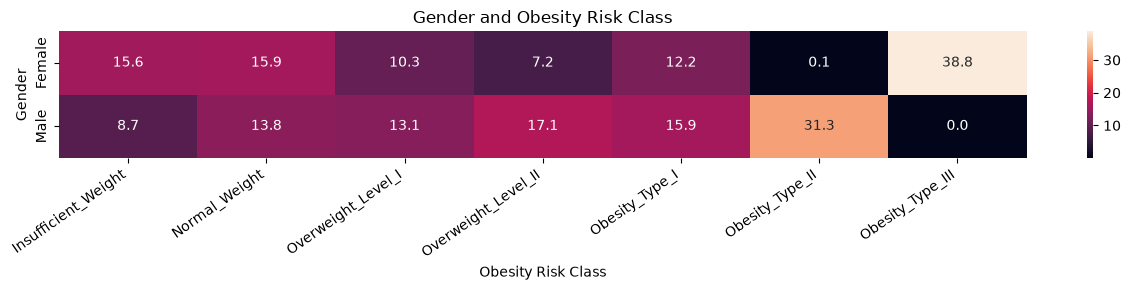

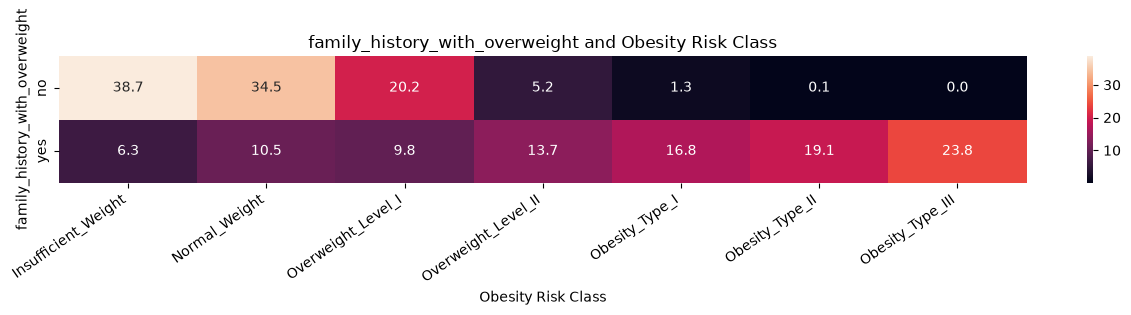

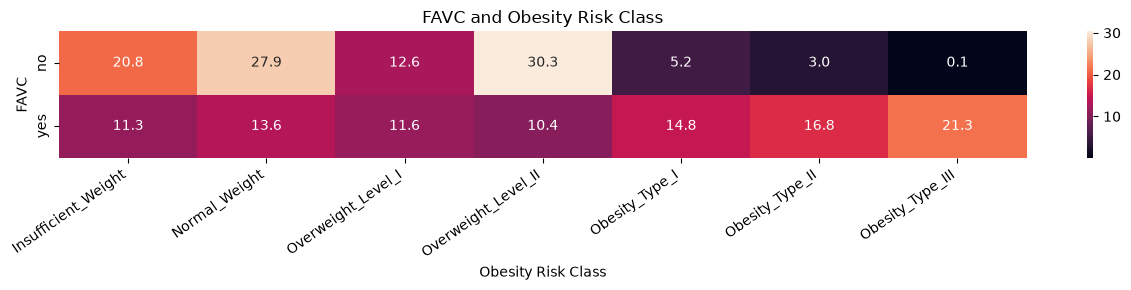

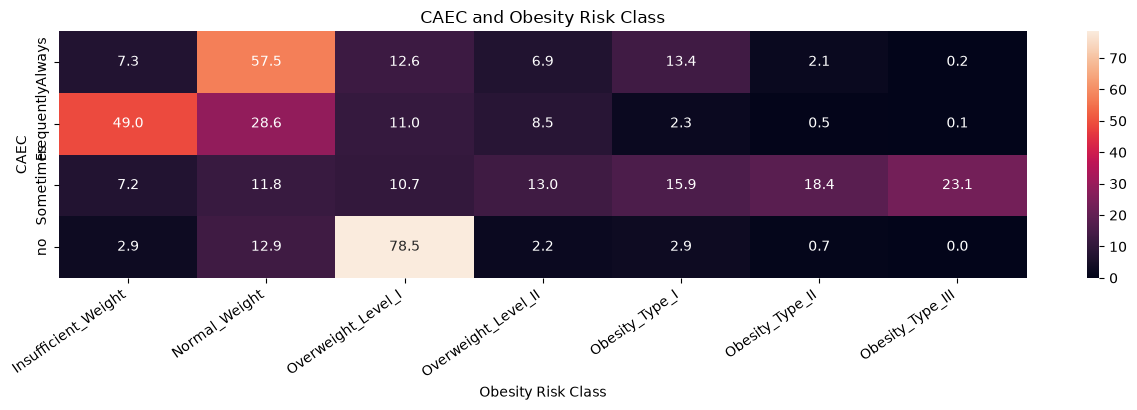

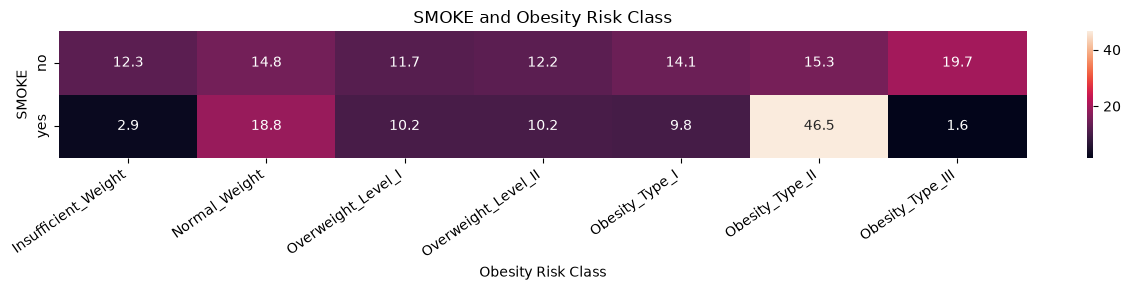

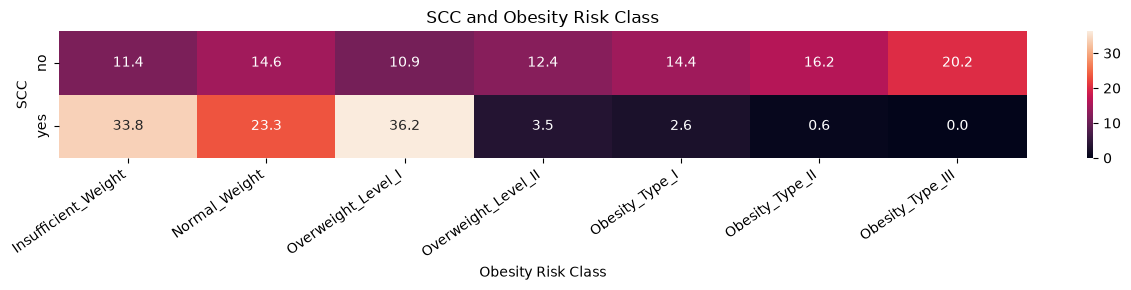

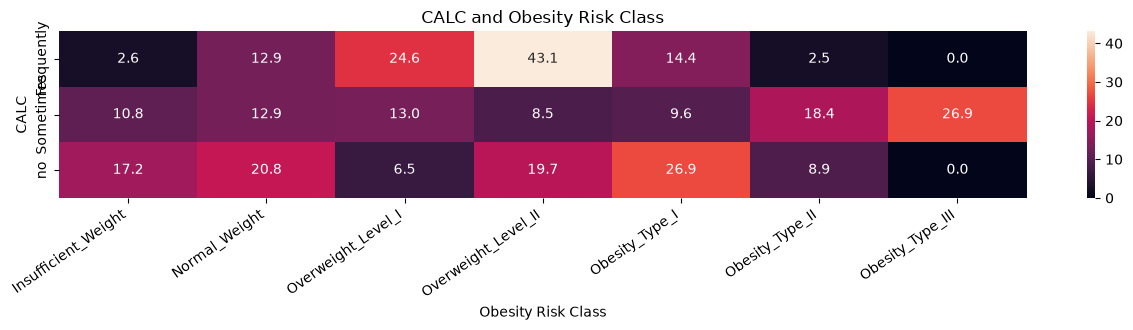

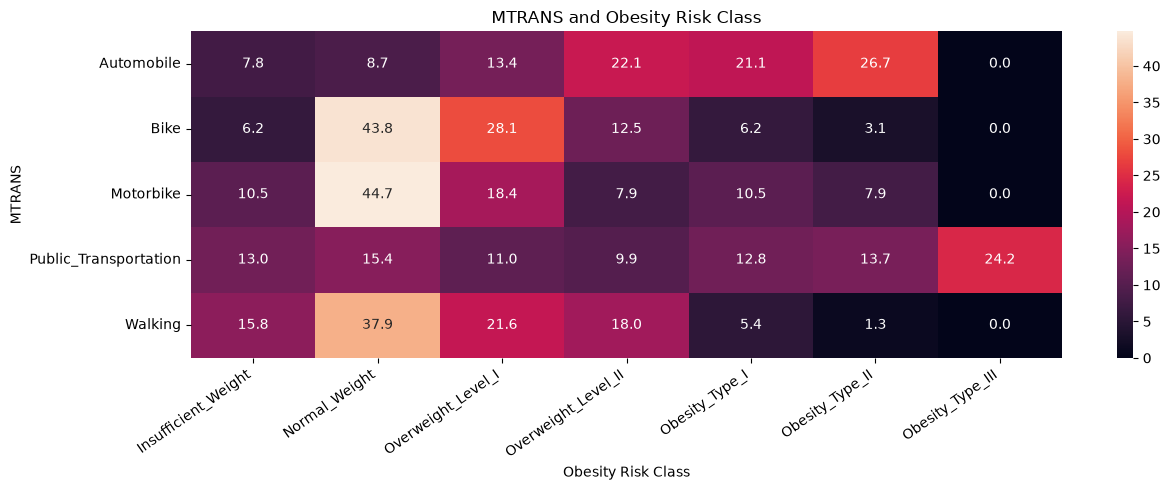

In [14]:
for column in categorical_features:
    percentage_table = (
        pd.crosstab(
            df[column],
            df[target_column],
            normalize="index",
        )
        .mul(100)
        .reindex(columns=class_order)
    )

    chart_height = max(3, len(percentage_table) * 0.8 + 1)

    plt.figure(figsize=(13, chart_height))

    sns.heatmap(
        percentage_table,
        annot=True,
        fmt=".1f",
    )

    plt.title(f"{column} and Obesity Risk Class")
    plt.xlabel("Obesity Risk Class")
    plt.ylabel(column)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

In [15]:
eda_df = df.copy()

eda_df["BMI"] = (
    eda_df["Weight"]
    / eda_df["Height"].pow(2)
)

eda_df["BMI"].describe().round(2)

count    20758.00
mean        30.24
std          8.33
min         12.87
25%         24.09
50%         29.38
75%         37.01
max         55.00
Name: BMI, dtype: float64

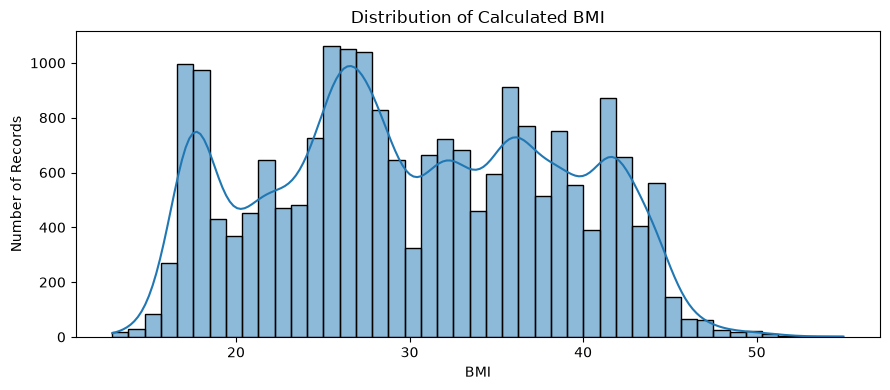

In [16]:
plt.figure(figsize=(9, 4))

sns.histplot(
    data=eda_df,
    x="BMI",
    kde=True,
)

plt.title("Distribution of Calculated BMI")
plt.xlabel("BMI")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

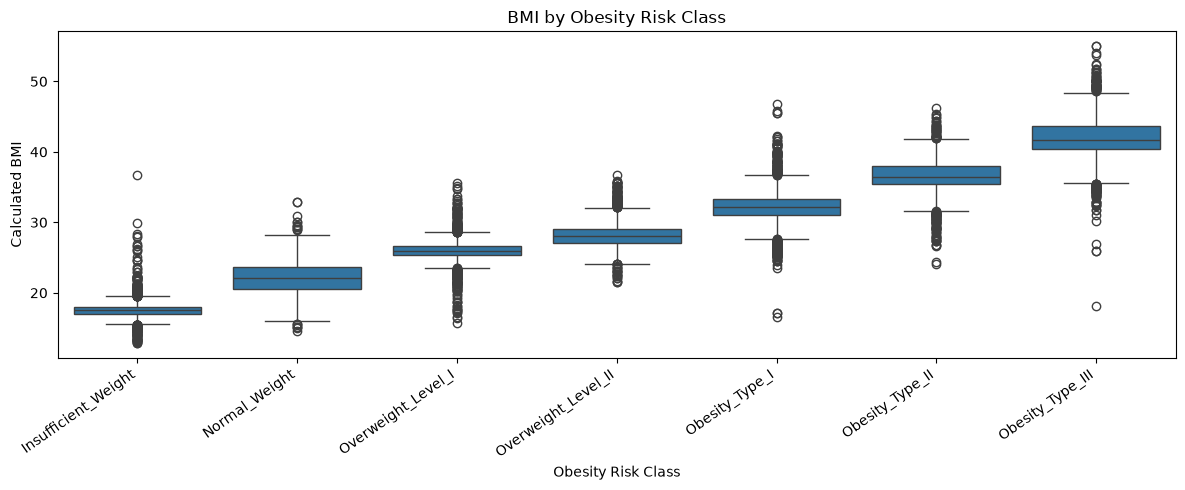

In [17]:
plt.figure(figsize=(12, 5))

sns.boxplot(
    data=eda_df,
    x=target_column,
    y="BMI",
    order=class_order,
)

plt.title("BMI by Obesity Risk Class")
plt.xlabel("Obesity Risk Class")
plt.ylabel("Calculated BMI")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [18]:
bmi_class_summary = (
    eda_df.groupby(target_column)["BMI"]
    .agg(["count", "mean", "median", "min", "max"])
    .reindex(class_order)
    .round(2)
)

bmi_class_summary

,count,mean,median,min,max
NObeyesdad,,,,,
Insufficient_Weight,2523,17.58,17.51,12.87,36.78
Normal_Weight,3082,22.00,22.04,14.63,32.88
Overweight_Level_I,2427,26.06,25.96,15.76,35.56
Overweight_Level_II,2522,28.19,28.02,21.51,36.74
Obesity_Type_I,2910,32.15,32.12,16.60,46.81
Obesity_Type_II,3248,36.52,36.38,24.05,46.22
Obesity_Type_III,4046,41.78,41.75,18.18,55.00


In [19]:
target_mapping = {
    class_name: class_number
    for class_number, class_name in enumerate(class_order)
}

eda_df["Target_Order"] = (
    eda_df[target_column]
    .map(target_mapping)
)

eda_df[
    [target_column, "Target_Order"]
].drop_duplicates().sort_values("Target_Order")

,NObeyesdad,Target_Order
2,Insufficient_Weight,0
1,Normal_Weight,1
8,Overweight_Level_I,2
0,Overweight_Level_II,3
12,Obesity_Type_I,4
6,Obesity_Type_II,5
3,Obesity_Type_III,6


In [20]:
correlation_columns = (
    numerical_features
    + ["BMI", "Target_Order"]
)

spearman_correlation = (
    eda_df[correlation_columns]
    .corr(method="spearman")
)

spearman_correlation.round(2)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,BMI,Target_Order
Age,1.00,0.02,0.44,0.10,-0.12,0.09,-0.28,-0.30,0.48,0.50
Height,0.02,1.00,0.42,-0.11,0.11,0.19,0.32,0.08,0.09,0.12
Weight,0.44,0.42,1.00,0.22,-0.02,0.35,-0.07,-0.07,0.93,0.91
FCVC,0.10,-0.11,0.22,1.00,0.13,0.11,-0.10,-0.13,0.30,0.31
NCP,-0.12,0.11,-0.02,0.13,1.00,0.08,0.11,0.13,-0.04,-0.05
CH2O,0.09,0.19,0.35,0.11,0.08,1.00,0.06,-0.00,0.31,0.30
FAF,-0.28,0.32,-0.07,-0.10,0.11,0.06,1.00,-0.01,-0.20,-0.23
TUE,-0.30,0.08,-0.07,-0.13,0.13,-0.00,-0.01,1.00,-0.09,-0.09
BMI,0.48,0.09,0.93,0.30,-0.04,0.31,-0.20,-0.09,1.00,0.97
Target_Order,0.50,0.12,0.91,0.31,-0.05,0.30,-0.23,-0.09,0.97,1.00


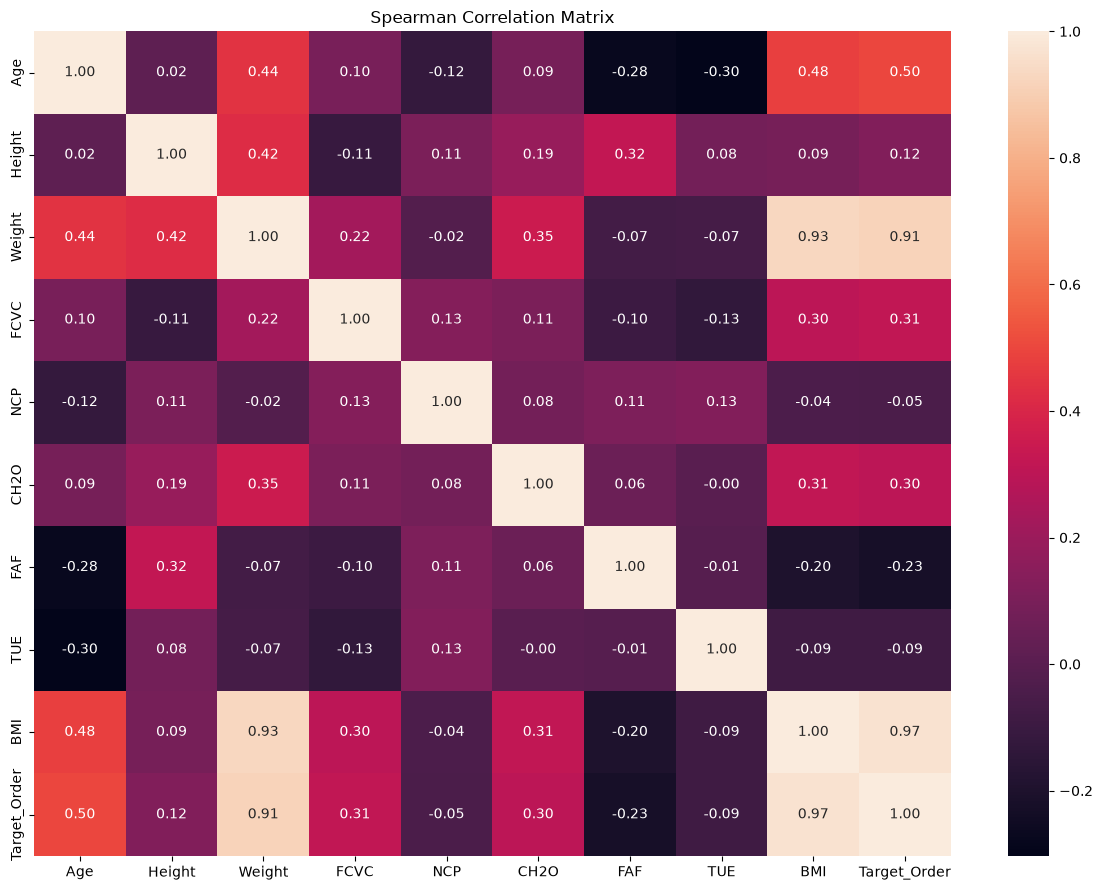

In [21]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    spearman_correlation,
    annot=True,
    fmt=".2f",
)

plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

In [22]:
target_correlations = (
    spearman_correlation["Target_Order"]
    .drop("Target_Order")
    .sort_values(
        key=lambda values: values.abs(),
        ascending=False,
    )
    .to_frame(name="Spearman correlation")
)

target_correlations

,Spearman correlation
BMI,0.967988
Weight,0.914899
Age,0.497429
FCVC,0.313013
CH2O,0.301579
FAF,-0.225321
Height,0.121465
TUE,-0.087855
NCP,-0.048091
